<a href="https://colab.research.google.com/github/oluwafemi244/facility-maintenance-energy-decision-support/blob/main/notebooks/04_sensitivity_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sensitivity Analysis of the Maintenance Prioritization Framework

## Facility Maintenance and Energy Decision Support Framework

This notebook examines how the preliminary maintenance prioritization and resource allocation results change when key demonstration assumptions are varied.

The preceding proof of concept combined estimated failure probability with simulated operational criticality and expected downtime and then applied simulated budget, labor, and spare parts constraints.

Because several of those inputs and weights are demonstration assumptions rather than validated facility specific parameters, this stage tests whether the resulting rankings and maintenance selections are sensitive to changes in:

1. the relative weighting of operational criticality and expected downtime;
2. the available maintenance budget;
3. the available maintenance labor;
4. the combination of budget and labor constraints; and
5. the composition of the demonstration portfolio.

The purpose is not to establish operationally valid thresholds. It is to identify which assumptions materially influence the proof of concept results and to document those limitations before further development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

In [2]:
!pip -q install pulp

In [3]:
import pulp

In [4]:
priority_url = (
    "https://raw.githubusercontent.com/"
    "oluwafemi244/facility-maintenance-energy-decision-support/"
    "main/results/maintenance_priority_results.csv"
)

portfolio = pd.read_csv(priority_url)

print("Maintenance priority results loaded successfully.")
print(f"Assets: {len(portfolio)}")
print(f"Columns: {portfolio.shape[1]}")

portfolio.head()

Maintenance priority results loaded successfully.
Assets: 60
Columns: 22


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type,Actual Machine Failure,Estimated Failure Probability,Preliminary Risk Band,Asset ID,Operational Criticality,Expected Downtime Hours,Maintenance Cost,Labor Hours Required,Spare Parts Available,Criticality Normalized,Downtime Normalized,Consequence Index,Maintenance Risk Score,Maintenance Risk Score 0-100,Priority Rank,Priority Category
0,298.9,310.2,2737,8.8,142,L,1,0.876667,Very High,ASSET-001,1,67,7435,38,1,0.2,0.954545,0.501818,0.439927,43.992727,1,High
1,302.6,311.6,1227,68.2,187,M,1,0.510000,High,ASSET-002,4,55,10524,9,1,0.8,0.772727,0.789091,0.402436,40.243636,2,High
2,302.7,311.1,1297,60.7,125,M,1,0.253333,Moderate,ASSET-003,4,29,10335,22,0,0.8,0.378788,0.631515,0.159984,15.998384,3,Moderate
3,299.4,310.8,1622,33.6,217,L,0,0.163333,Elevated,ASSET-004,3,70,7860,29,1,0.6,1.000000,0.760000,0.124133,12.413333,4,Low
4,300.5,310.2,1386,48.2,225,M,0,0.110000,Elevated,ASSET-005,3,32,13044,22,0,0.6,0.424242,0.529697,0.058267,5.826667,5,Low


In [6]:
required_columns = [
    "Asset ID",
    "Estimated Failure Probability",
    "Operational Criticality",
    "Expected Downtime Hours",
    "Maintenance Cost",
    "Labor Hours Required",
    "Spare Parts Available"
]

missing_columns = [
    column
    for column in required_columns
    if column not in portfolio.columns
]

print("Missing required columns:", missing_columns)

Missing required columns: []


## Sensitivity to Consequence Weights

The original proof of concept assigned 60% of the consequence index to operational criticality and 40% to expected downtime.

Because these values are demonstration assumptions, alternative weighting combinations are tested below.

The analysis does not seek to identify a universally correct weighting scheme. It examines whether maintenance rankings change materially when greater importance is assigned to either operational criticality or downtime.

In [8]:
portfolio["Criticality Normalized"] = (
    portfolio["Operational Criticality"] / 5
)

downtime_min = portfolio["Expected Downtime Hours"].min()
downtime_max = portfolio["Expected Downtime Hours"].max()

portfolio["Downtime Normalized"] = (
    portfolio["Expected Downtime Hours"] - downtime_min
) / (
    downtime_max - downtime_min
)

In [9]:
weight_scenarios = [
    (0.20, 0.80),
    (0.40, 0.60),
    (0.50, 0.50),
    (0.60, 0.40),
    (0.80, 0.20)
]

weight_results = []

for criticality_weight, downtime_weight in weight_scenarios:

    consequence = (
        criticality_weight
        * portfolio["Criticality Normalized"]
        +
        downtime_weight
        * portfolio["Downtime Normalized"]
    )

    risk = (
        portfolio["Estimated Failure Probability"]
        * consequence
        * 100
    )

    temp = pd.DataFrame({
        "Asset ID": portfolio["Asset ID"],
        "Risk Score": risk
    })

    temp = temp.sort_values(
        "Risk Score",
        ascending=False
    ).reset_index(drop=True)

    temp["Rank"] = np.arange(
        1,
        len(temp) + 1
    )

    for _, row in temp.iterrows():

        weight_results.append({
            "Criticality Weight": criticality_weight,
            "Downtime Weight": downtime_weight,
            "Asset ID": row["Asset ID"],
            "Risk Score": row["Risk Score"],
            "Rank": row["Rank"]
        })

weight_results_df = pd.DataFrame(weight_results)

weight_results_df.head()

,Criticality Weight,Downtime Weight,Asset ID,Risk Score,Rank
0,0.2,0.8,ASSET-001,70.452121,1
1,0.2,0.8,ASSET-002,39.687273,2
2,0.2,0.8,ASSET-004,15.026667,3
3,0.2,0.8,ASSET-003,11.730101,4
4,0.2,0.8,ASSET-005,5.053333,5


In [10]:
top_10_by_weight = (
    weight_results_df[
        weight_results_df["Rank"] <= 10
    ]
    .sort_values(
        [
            "Criticality Weight",
            "Rank"
        ]
    )
)

top_10_by_weight

,Criticality Weight,Downtime Weight,Asset ID,Risk Score,Rank
0,0.2,0.8,ASSET-001,70.452121,1
1,0.2,0.8,ASSET-002,39.687273,2
2,0.2,0.8,ASSET-004,15.026667,3
3,0.2,0.8,ASSET-003,11.730101,4
4,0.2,0.8,ASSET-005,5.053333,5
5,0.2,0.8,ASSET-007,3.957576,6
6,0.2,0.8,ASSET-006,3.111111,7
7,0.2,0.8,ASSET-008,1.697778,8
8,0.2,0.8,ASSET-011,1.290909,9
9,0.2,0.8,ASSET-010,0.855758,10


In [11]:
top10_frequency = (
    top_10_by_weight
    .groupby("Asset ID")
    .size()
    .reset_index(name="Times in Top 10")
    .sort_values(
        "Times in Top 10",
        ascending=False
    )
)

top10_frequency.head(20)

,Asset ID,Times in Top 10
0,ASSET-001,5
1,ASSET-002,5
2,ASSET-003,5
3,ASSET-004,5
4,ASSET-005,5
5,ASSET-006,5
6,ASSET-007,5
7,ASSET-008,5
10,ASSET-011,5
9,ASSET-010,3


In [12]:
rank_pivot = weight_results_df.pivot(
    index="Asset ID",
    columns="Criticality Weight",
    values="Rank"
)

rank_pivot.columns = [
    f"Criticality Weight {weight:.1f}"
    for weight in rank_pivot.columns
]

rank_pivot["Minimum Rank"] = rank_pivot.min(axis=1)
rank_pivot["Maximum Rank"] = rank_pivot.max(axis=1)

rank_pivot["Rank Range"] = (
    rank_pivot["Maximum Rank"]
    - rank_pivot["Minimum Rank"]
)

rank_pivot = rank_pivot.sort_values(
    "Rank Range",
    ascending=False
)

rank_pivot.head(15)

,Criticality Weight 0.2,Criticality Weight 0.4,Criticality Weight 0.5,Criticality Weight 0.6,Criticality Weight 0.8,Minimum Rank,Maximum Rank,Rank Range
Asset ID,,,,,,,,
ASSET-010,10,10,10,13,14,10,14,4
ASSET-012,15,13,13,11,11,11,15,4
ASSET-009,13,12,12,10,10,10,13,3
ASSET-014,19,17,16,16,16,16,19,3
ASSET-021,16,16,18,18,18,16,18,2
ASSET-020,17,19,19,19,19,17,19,2
ASSET-015,12,14,14,14,13,12,14,2
ASSET-007,6,7,7,7,8,6,8,2
ASSET-004,3,4,4,4,4,3,4,1


## Sensitivity to Maintenance Budget

The initial resource allocation demonstration used a simulated maintenance budget of $120,000.

This section evaluates several alternative budgets while holding the available labor capacity at 240 hours.

The purpose is to examine how resource scarcity changes the number of selected maintenance actions and the total modeled risk addressed.

In [13]:
def solve_maintenance_allocation(
    data,
    budget,
    labor_hours,
    risk_column="Maintenance Risk Score 0-100"
):

    model = pulp.LpProblem(
        "Maintenance_Allocation",
        pulp.LpMaximize
    )

    decision = {
        i: pulp.LpVariable(
            f"select_{i}",
            cat="Binary"
        )
        for i in data.index
    }

    model += pulp.lpSum(
        decision[i] * data.loc[i, risk_column]
        for i in data.index
    )

    model += (
        pulp.lpSum(
            decision[i]
            * data.loc[i, "Maintenance Cost"]
            for i in data.index
        )
        <= budget
    )

    model += (
        pulp.lpSum(
            decision[i]
            * data.loc[i, "Labor Hours Required"]
            for i in data.index
        )
        <= labor_hours
    )

    for i in data.index:

        if data.loc[i, "Spare Parts Available"] == 0:
            model += decision[i] == 0

    model.solve(
        pulp.PULP_CBC_CMD(msg=False)
    )

    selected_indices = [
        i
        for i in data.index
        if pulp.value(decision[i]) == 1
    ]

    selected = data.loc[
        selected_indices
    ].copy()

    return {
        "Status": pulp.LpStatus[model.status],
        "Assets Selected": len(selected),
        "Total Cost": selected["Maintenance Cost"].sum(),
        "Labor Hours": selected["Labor Hours Required"].sum(),
        "Total Risk Addressed": selected[risk_column].sum(),
        "Selected Assets": selected["Asset ID"].tolist()
    }

In [14]:
budget_levels = [
    40000,
    60000,
    80000,
    100000,
    120000,
    150000,
    180000
]

budget_results = []

for budget in budget_levels:

    result = solve_maintenance_allocation(
        portfolio,
        budget=budget,
        labor_hours=240
    )

    budget_results.append({
        "Budget": budget,
        "Status": result["Status"],
        "Assets Selected": result["Assets Selected"],
        "Total Cost": result["Total Cost"],
        "Labor Hours": result["Labor Hours"],
        "Total Risk Addressed": result["Total Risk Addressed"]
    })

budget_results_df = pd.DataFrame(
    budget_results
)

budget_results_df

,Budget,Status,Assets Selected,Total Cost,Labor Hours,Total Risk Addressed
0,40000,Optimal,6,39435,114,104.087677
1,60000,Optimal,8,58347,188,106.509495
2,80000,Optimal,11,79381,228,107.560000
3,100000,Optimal,11,83656,236,107.766465
4,120000,Optimal,11,83656,236,107.766465
5,150000,Optimal,11,83656,236,107.766465
6,180000,Optimal,11,83656,236,107.766465


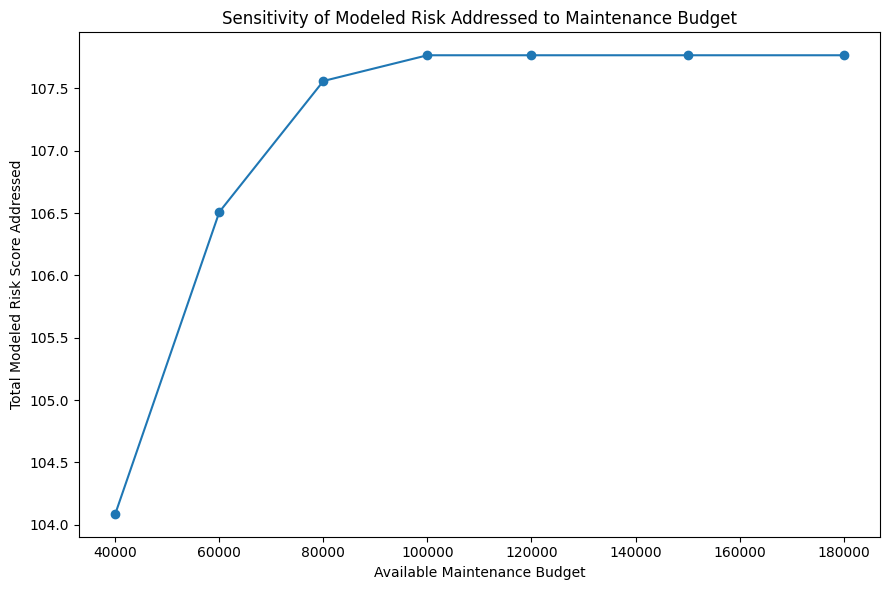

In [15]:
plt.figure(figsize=(9, 6))

plt.plot(
    budget_results_df["Budget"],
    budget_results_df["Total Risk Addressed"],
    marker="o"
)

plt.title(
    "Sensitivity of Modeled Risk Addressed to Maintenance Budget"
)

plt.xlabel("Available Maintenance Budget")
plt.ylabel("Total Modeled Risk Score Addressed")

plt.tight_layout()
plt.show()

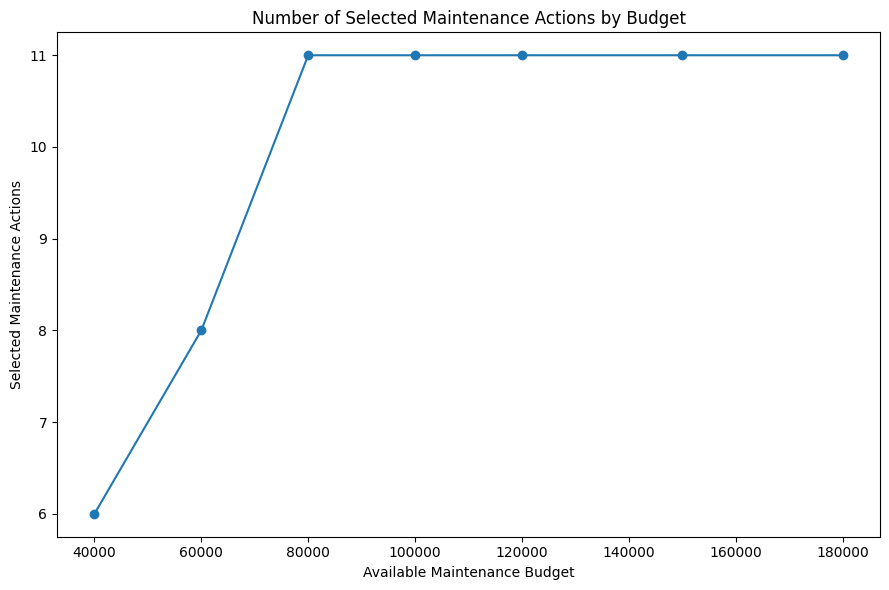

In [16]:
plt.figure(figsize=(9, 6))

plt.plot(
    budget_results_df["Budget"],
    budget_results_df["Assets Selected"],
    marker="o"
)

plt.title(
    "Number of Selected Maintenance Actions by Budget"
)

plt.xlabel("Available Maintenance Budget")
plt.ylabel("Selected Maintenance Actions")

plt.tight_layout()
plt.show()

## Sensitivity to Available Maintenance Labor

The initial proof of concept assumed 240 available maintenance labor hours.

This section varies labor availability while holding the simulated maintenance budget at $120,000.

The analysis examines whether labor capacity, rather than financial resources, becomes the binding constraint on the selected maintenance program.

In [17]:
labor_levels = [
    80,
    120,
    160,
    200,
    240,
    300,
    360
]

labor_results = []

for labor in labor_levels:

    result = solve_maintenance_allocation(
        portfolio,
        budget=120000,
        labor_hours=labor
    )

    labor_results.append({
        "Labor Hours Available": labor,
        "Status": result["Status"],
        "Assets Selected": result["Assets Selected"],
        "Total Cost": result["Total Cost"],
        "Labor Used": result["Labor Hours"],
        "Total Risk Addressed": result["Total Risk Addressed"]
    })

labor_results_df = pd.DataFrame(
    labor_results
)

labor_results_df

,Labor Hours Available,Status,Assets Selected,Total Cost,Labor Used,Total Risk Addressed
0,80,Optimal,3,25819,76,96.649697
1,120,Optimal,6,39435,114,104.087677
2,160,Optimal,8,58637,158,105.861010
3,200,Optimal,9,74743,194,106.821818
4,240,Optimal,11,83656,236,107.766465
5,300,Optimal,14,112571,300,108.595960
6,360,Optimal,15,116968,337,108.736566


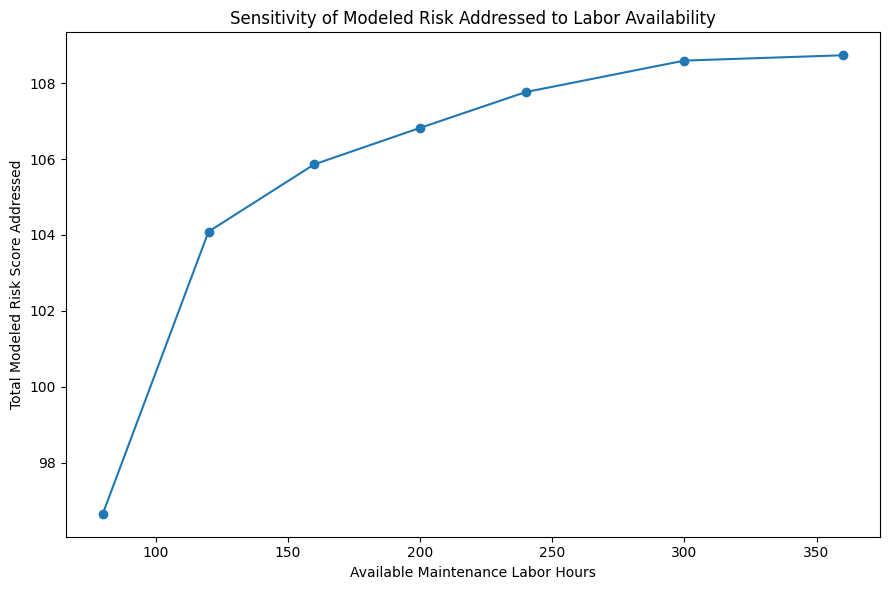

In [18]:
plt.figure(figsize=(9, 6))

plt.plot(
    labor_results_df["Labor Hours Available"],
    labor_results_df["Total Risk Addressed"],
    marker="o"
)

plt.title(
    "Sensitivity of Modeled Risk Addressed to Labor Availability"
)

plt.xlabel("Available Maintenance Labor Hours")
plt.ylabel("Total Modeled Risk Score Addressed")

plt.tight_layout()
plt.show()

In [19]:
combined_results = []

for budget in [
    60000,
    90000,
    120000,
    150000
]:

    for labor in [
        120,
        180,
        240,
        300
    ]:

        result = solve_maintenance_allocation(
            portfolio,
            budget=budget,
            labor_hours=labor
        )

        combined_results.append({
            "Budget": budget,
            "Labor Hours Available": labor,
            "Assets Selected": result["Assets Selected"],
            "Total Cost": result["Total Cost"],
            "Labor Used": result["Labor Hours"],
            "Total Risk Addressed": result["Total Risk Addressed"]
        })

combined_results_df = pd.DataFrame(
    combined_results
)

combined_results_df

,Budget,Labor Hours Available,Assets Selected,Total Cost,Labor Used,Total Risk Addressed
0,60000,120,6,39435,114,104.087677
1,60000,180,8,59443,176,106.458586
2,60000,240,8,58347,188,106.509495
3,60000,300,8,58347,188,106.509495
4,90000,120,6,39435,114,104.087677
5,90000,180,8,65694,177,106.469495
6,90000,240,11,83656,236,107.766465
7,90000,300,11,89697,259,107.999596
8,120000,120,6,39435,114,104.087677
9,120000,180,8,65694,177,106.469495


In [20]:
risk_matrix = combined_results_df.pivot(
    index="Labor Hours Available",
    columns="Budget",
    values="Total Risk Addressed"
)

risk_matrix.round(2)

Budget,60000,90000,120000,150000
Labor Hours Available,,,,
120,104.09,104.09,104.09,104.09
180,106.46,106.47,106.47,106.47
240,106.51,107.77,107.77,107.77
300,106.51,108.00,108.60,108.60


## Sensitivity to Demonstration Portfolio Composition

The current proof of concept portfolio contains a large proportion of observations with very low modeled failure probabilities.

This reflects the way the demonstration portfolio was initially sampled from the AI4I test predictions and limits the conclusions that can be drawn from the present resource allocation exercise.

The portfolio is therefore useful for demonstrating that the computational pipeline functions, but it should not be interpreted as representative of the risk distribution of an actual industrial facility.

Future validation will include alternative portfolios with greater representation across low, moderate, and high modeled risk conditions and, where available, real or independently published equipment records.

In [21]:
portfolio_summary = (
    portfolio["Priority Category"]
    .value_counts()
    .rename_axis("Priority Category")
    .reset_index(name="Number of Assets")
)

portfolio_summary

,Priority Category,Number of Assets
0,Low,57
1,High,2
2,Moderate,1


In [22]:
portfolio_summary["Percentage"] = (
    portfolio_summary["Number of Assets"]
    / len(portfolio)
    * 100
).round(2)

portfolio_summary

,Priority Category,Number of Assets,Percentage
0,Low,57,95.00
1,High,2,3.33
2,Moderate,1,1.67


In [23]:
weight_results_df.to_csv(
    "/content/weight_sensitivity_results.csv",
    index=False
)

rank_pivot.to_csv(
    "/content/rank_stability_results.csv"
)

budget_results_df.to_csv(
    "/content/budget_sensitivity_results.csv",
    index=False
)

labor_results_df.to_csv(
    "/content/labor_sensitivity_results.csv",
    index=False
)

combined_results_df.to_csv(
    "/content/combined_resource_sensitivity.csv",
    index=False
)

portfolio_summary.to_csv(
    "/content/portfolio_composition_summary.csv",
    index=False
)

print("Sensitivity result files created successfully.")

Sensitivity result files created successfully.


## Preliminary Sensitivity Analysis Conclusions

This stage evaluates whether the maintenance-prioritization and resource-allocation proof-of-concept is sensitive to changes in assumptions that have not yet been validated for a specific operating facility.

The analysis varies the relative weighting of operational criticality and expected downtime, maintenance budget, labor capacity, and combinations of budget and labor constraints.

The results provide a basis for identifying which assumptions materially affect asset rankings and selected maintenance actions.

This sensitivity analysis is particularly important because the consequence weights, resource limits, and facility-context variables used in the current proof-of-concept are demonstration assumptions rather than operationally validated parameters.

The current demonstration portfolio also contains a substantial concentration of low modeled-risk observations. This limitation is documented rather than treated as representative of an actual facility risk distribution.

The sensitivity results will therefore be used to guide the next development stage, including refinement of the framework architecture, validation strategy, data requirements, and future testing on additional datasets and alternative asset portfolios.

No result in this notebook is presented as a validated operational maintenance recommendation.